# EU Market Pulse — Exploratory Data Analysis & Business KPIs

## Objective

This notebook explores the cleaned dataset (`data/processed/eu_market_pulse_clean.csv`) 
to understand patterns across the 19 countries in scope, and defines a set of 
business KPIs that answer the project's central question: **"Where should a 
remote-first company expand or hire in Europe, based on cost of living and 
inflation trends?"**

## Structure

1. Load processed data and basic statistics
2. Trend and correlation exploration
3. Business KPI definition and calculation
4. Key visualizations supporting the analysis

## 1. Load Processed Data

We load the cleaned, merged dataset produced in the previous notebook and 
confirm its structure before starting the analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/eu_market_pulse_clean.csv')

print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print(f"Year range: {df['year'].min()}–{df['year'].max()}")
df.head()

Shape: (222, 6)
Countries: 19
Year range: 2014–2025


,country,year,inflation_rate,price_level_index,house_price_index,house_price_flag
0,Austria,2014,1.5,109.3,NaN,NaN
1,Austria,2015,0.8,109.3,NaN,NaN
2,Austria,2016,1.0,110.4,105.27,NaN
3,Austria,2017,2.2,111.6,108.56,NaN
4,Austria,2018,2.1,112.1,112.62,NaN


## 2. Descriptive Statistics

We start with a high-level statistical summary of the three core metrics 
across all countries and years, to understand overall ranges and variability 
before drilling into country-level patterns.

In [2]:
df[['inflation_rate', 'price_level_index', 'house_price_index']].describe()

,inflation_rate,price_level_index,house_price_index
count,222.000000,222.000000,170.000000
mean,2.464865,105.631982,120.851471
std,3.099851,28.218209,22.112050
min,-1.400000,53.800000,81.900000
25%,0.500000,87.300000,104.667500
50%,1.600000,109.300000,116.125000
75%,3.000000,123.625000,130.505000
max,17.000000,173.000000,206.410000


## 3. Country-Level Aggregation

To compare countries directly, we aggregate each metric by country: average 
inflation rate (proxy for long-term price stability), most recent price 
level index (current cost of living vs. EU average), and average house price 
growth. This aggregated view is the foundation for the business KPIs defined 
in the next section.

In [3]:
# Average inflation rate per country (2014-2025) — stability proxy
avg_inflation = df.groupby('country')['inflation_rate'].mean().round(2).sort_values()

# Most recent price level index per country (2025) — current cost of living
latest_year = df['year'].max()
latest_price_level = df[df['year'] == latest_year].set_index('country')['price_level_index'].sort_values()

# Average house price index growth per country (first vs last available year)
house_growth = (
    df.dropna(subset=['house_price_index'])
    .groupby('country')['house_price_index']
    .agg(['first', 'last'])
)
house_growth['pct_change'] = ((house_growth['last'] - house_growth['first']) / house_growth['first'] * 100).round(1)

print("=== Average Inflation Rate 2014-2025 (lowest to highest) ===")
print(avg_inflation)
print(f"\n=== Price Level Index in {latest_year} (cheapest to most expensive) ===")
print(latest_price_level)
print(f"\n=== House Price % Change (first available year to {latest_year}) ===")
print(house_growth[['pct_change']].sort_values('pct_change'))

=== Average Inflation Rate 2014-2025 (lowest to highest) ===
country
Switzerland       0.54
United Kingdom    1.53
Greece            1.55
Denmark           1.69
Ireland           1.72
Finland           1.78
Italy             1.88
Portugal          1.92
France            1.92
Spain             1.95
Sweden            2.47
Germany           2.50
Netherlands       2.67
Belgium           2.68
Austria           3.01
Poland            3.67
Czechia           3.90
Romania           4.14
Hungary           4.85
Name: inflation_rate, dtype: float64

=== Price Level Index in 2025 (cheapest to most expensive) ===
country
Romania         65.1
Poland          73.3
Hungary         77.5
Portugal        86.6
Greece          87.4
Czechia         89.4
Spain           91.6
Italy           97.1
Germany        108.3
France         110.3
Austria        113.0
Netherlands    115.6
Belgium        116.2
Finland        120.8
Sweden         121.0
Ireland        136.2
Denmark        139.7
Switzerland    171.3
Name: p

In [4]:
house_years_available = df.dropna(subset=['house_price_index']).groupby('country')['year'].agg(['min', 'max', 'count'])
print(house_years_available.sort_values('count'))

              min   max  count
country                       
Austria      2016  2025     10
Belgium      2016  2025     10
Czechia      2016  2025     10
Denmark      2016  2025     10
Finland      2016  2025     10
France       2016  2025     10
Germany      2016  2025     10
Greece       2016  2025     10
Hungary      2016  2025     10
Ireland      2016  2025     10
Italy        2016  2025     10
Netherlands  2016  2025     10
Poland       2016  2025     10
Portugal     2016  2025     10
Romania      2016  2025     10
Spain        2016  2025     10
Sweden       2016  2025     10


### Data Consistency Confirmed

All 17 countries with house price data share the same coverage window 
(2016–2025, 10 years), confirming that percentage growth figures are directly 
comparable across countries with no distortion from uneven time periods.

## 4. Business KPI Definition

To directly answer the project's central question, we define a composite 
scoring system based on three dimensions:

1. **Cost of Living** — current price level vs. EU average (`price_level_index`, latest year)
2. **Inflation Stability** — average inflation rate over the period
3. **Housing Pressure** — house price growth over the period

### ⚠️ Score Direction: Higher Is Always Better

Each dimension is normalized to a 0–100 scale where **100 = most favorable 
for expansion**, regardless of the raw metric's original direction (e.g. a 
country with the highest `price_level_index` gets the lowest 
`cost_of_living_score`). The three scores are combined into an **Overall 
Expansion Score**, a simple average giving equal weight to all three.

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Build a country-level summary table
kpi_df = pd.DataFrame({
    'avg_inflation_rate': avg_inflation,
    'price_level_2025': latest_price_level,
}).join(house_growth[['pct_change']].rename(columns={'pct_change': 'house_price_growth'}))

# Normalize each metric to 0-100, where 100 = most favorable for expansion
# Lower cost, lower inflation, lower housing growth = more favorable
kpi_df['cost_of_living_score'] = 100 - MinMaxScaler((0, 100)).fit_transform(kpi_df[['price_level_2025']])
kpi_df['inflation_stability_score'] = 100 - MinMaxScaler((0, 100)).fit_transform(kpi_df[['avg_inflation_rate']])
kpi_df['housing_pressure_score'] = 100 - MinMaxScaler((0, 100)).fit_transform(kpi_df[['house_price_growth']].fillna(kpi_df['house_price_growth'].mean()))

kpi_df['overall_expansion_score'] = (
    kpi_df['cost_of_living_score'] + 
    kpi_df['inflation_stability_score'] + 
    kpi_df['housing_pressure_score']
) / 3

kpi_df_sorted = kpi_df.sort_values('overall_expansion_score', ascending=False)
kpi_df_sorted[['cost_of_living_score', 'inflation_stability_score', 'housing_pressure_score', 'overall_expansion_score']].round(1)

,cost_of_living_score,inflation_stability_score,housing_pressure_score,overall_expansion_score
country,,,,
Italy,69.9,68.9,87.7,75.5
Finland,47.6,71.2,100.0,72.9
Romania,100.0,16.5,91.2,69.2
France,57.4,68.0,80.7,68.7
Spain,75.0,67.3,51.2,64.5
Sweden,47.4,55.2,89.1,63.9
Germany,59.3,54.5,75.2,63.0
Greece,79.0,76.6,33.4,63.0
Belgium,51.9,50.3,78.2,60.1


In [6]:
uk_price_levels = df[df['country'] == 'United Kingdom'][['year', 'price_level_index']]
print(uk_price_levels)

     year  price_level_index
216  2014              128.1
217  2015              142.6
218  2016              127.7
219  2017              119.6
220  2018              119.6
221  2019              120.9


### Data Limitation: United Kingdom Excluded from Cost of Living Comparison

The United Kingdom's `price_level_index` data stops in 2019, with no updates 
through 2025 in this Eurostat series — the gap begins precisely at the onset 
of the COVID-19 pandemic. Rather than comparing a 2019 (pre-pandemic) UK 
figure against 2025 (post-pandemic) figures for all other countries — which 
would conflate two different economic periods — the UK is excluded from the 
`cost_of_living_score` and `overall_expansion_score`. It remains included in 
the `inflation_stability_score` and `housing_pressure_score`, where data is 
complete through 2025.

In [7]:
# Recalculate cost_of_living_score and overall_expansion_score, 
# excluding countries without complete 2025 price level data (i.e. United Kingdom)
kpi_df_complete = kpi_df.dropna(subset=['price_level_2025']).copy()

kpi_df_complete['overall_expansion_score'] = (
    kpi_df_complete['cost_of_living_score'] + 
    kpi_df_complete['inflation_stability_score'] + 
    kpi_df_complete['housing_pressure_score']
) / 3

kpi_final = kpi_df_complete.sort_values('overall_expansion_score', ascending=False)
kpi_final[['cost_of_living_score', 'inflation_stability_score', 'housing_pressure_score', 'overall_expansion_score']].round(1)

,cost_of_living_score,inflation_stability_score,housing_pressure_score,overall_expansion_score
country,,,,
Italy,69.9,68.9,87.7,75.5
Finland,47.6,71.2,100.0,72.9
Romania,100.0,16.5,91.2,69.2
France,57.4,68.0,80.7,68.7
Spain,75.0,67.3,51.2,64.5
Sweden,47.4,55.2,89.1,63.9
Germany,59.3,54.5,75.2,63.0
Greece,79.0,76.6,33.4,63.0
Belgium,51.9,50.3,78.2,60.1


## 5. Key Visualizations

We now visualize the ranking and the underlying trade-offs to support the 
narrative: which countries offer the best balance of cost, stability, and 
housing pressure for a remote-first company considering expansion.

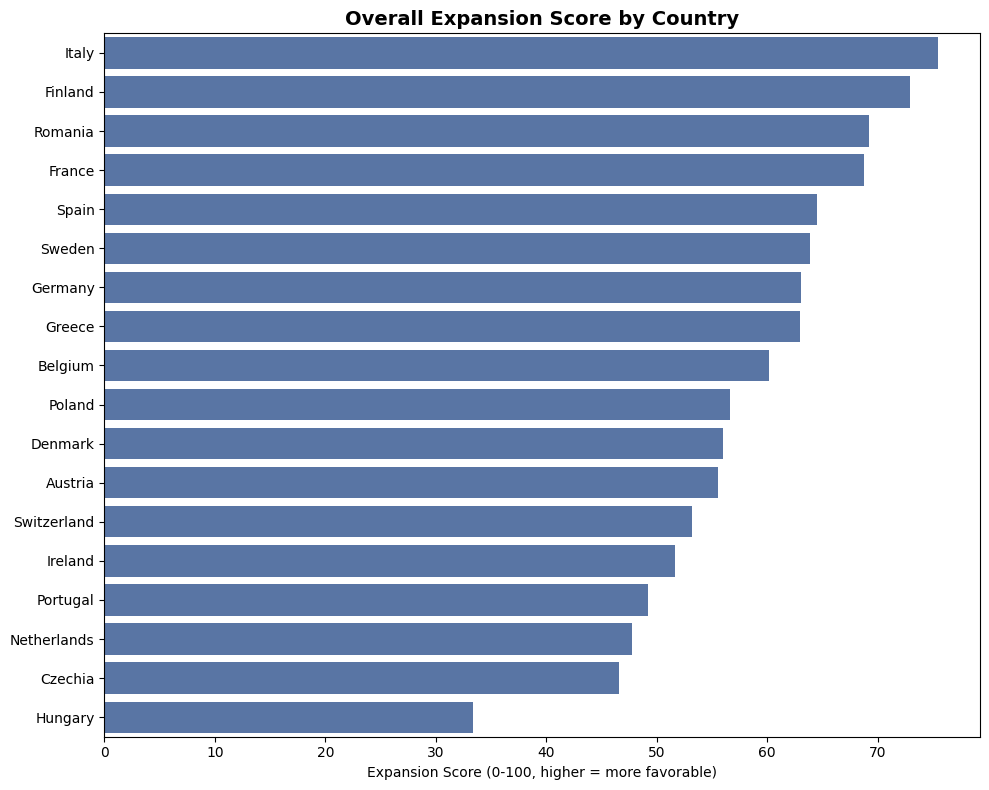

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    x=kpi_final['overall_expansion_score'], 
    y=kpi_final.index, 
    color='#4C72B0',
    ax=ax
)
ax.set_title('Overall Expansion Score by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Expansion Score (0-100, higher = more favorable)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../images/expansion_score_ranking.png', dpi=150)
plt.show()

### Insight: Overall Expansion Score

Italy, Finland, and Romania lead the ranking, each for different reasons: 
Italy offers a balanced profile across all three dimensions, Finland benefits 
from falling house prices offsetting a mid-range cost of living, and Romania 
combines the lowest cost of living in the sample with strong housing 
performance — though its inflation stability score is among the weakest, a 
trade-off worth flagging for any company prioritizing long-term cost 
predictability.

Hungary ranks last, driven primarily by inflation volatility and housing 
pressure rather than cost of living, where it actually scores well (88.3). 
This illustrates a key theme for the analysis: **low cost alone does not 
guarantee a favorable expansion environment** — stability matters as much 
as price.

Portugal sits mid-table (49.2), not due to cost of living (79.8, one of the 
more favorable scores) but due to the sharpest housing price growth in the 
sample (0.0 — the lowest possible housing pressure score). This is a notable 
signal for companies evaluating Portugal as a low-cost hub: affordability 
today does not guarantee affordability going forward.

### Cost vs. Inflation Trade-off

This scatter plot visualizes the core trade-off behind the expansion question: 
countries that are cheap but unstable (top-left) vs. countries that are 
stable but expensive (bottom-right) vs. the ideal quadrant — cheap AND stable 
(top-right).

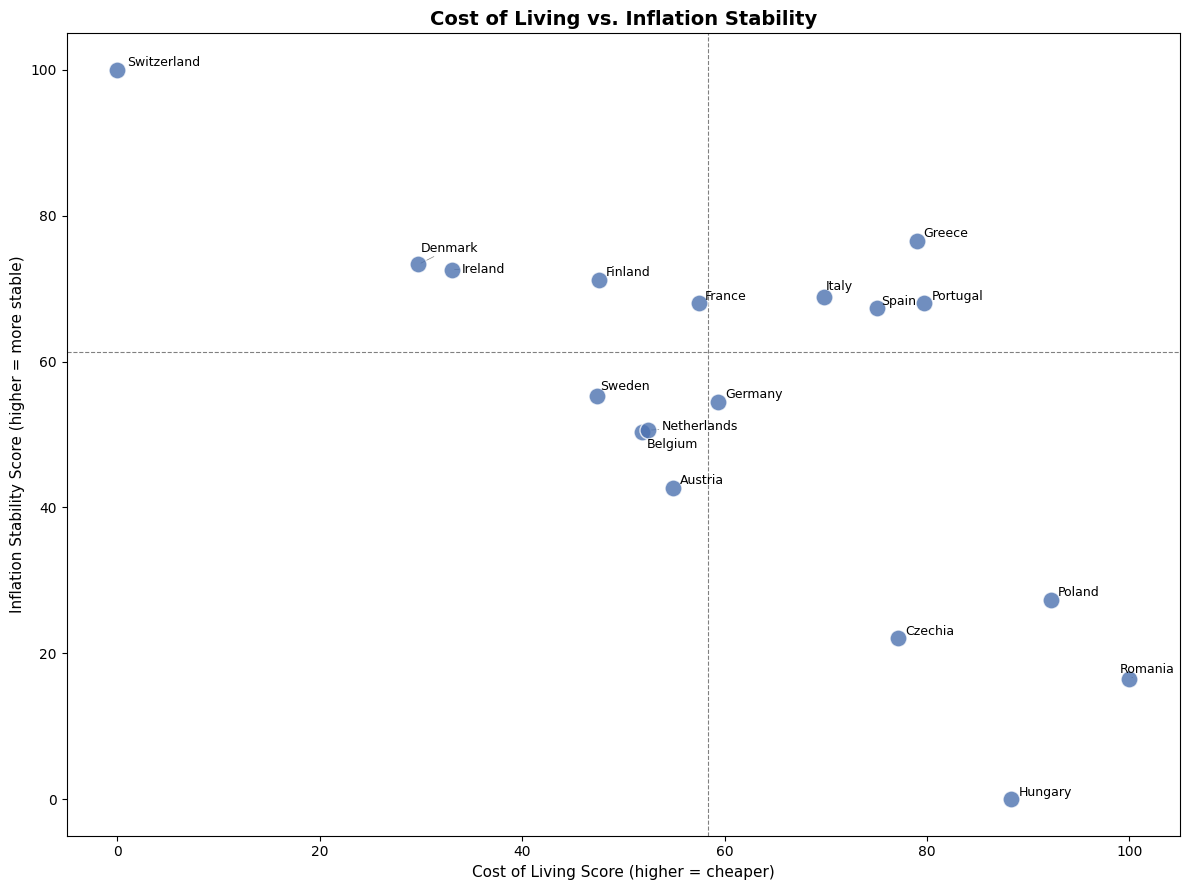

In [9]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(
    kpi_final['cost_of_living_score'], 
    kpi_final['inflation_stability_score'],
    s=150, color='#4C72B0', alpha=0.8, edgecolor='white', zorder=3
)

texts = [
    ax.text(row['cost_of_living_score'], row['inflation_stability_score'], country, fontsize=9)
    for country, row in kpi_final.iterrows()
]
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

ax.set_xlabel('Cost of Living Score (higher = cheaper)', fontsize=11)
ax.set_ylabel('Inflation Stability Score (higher = more stable)', fontsize=11)
ax.set_title('Cost of Living vs. Inflation Stability', fontsize=14, fontweight='bold')
ax.axhline(kpi_final['inflation_stability_score'].median(), color='grey', linestyle='--', linewidth=0.8)
ax.axvline(kpi_final['cost_of_living_score'].median(), color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('../images/cost_vs_inflation_scatter.png', dpi=150)
plt.show()

### Insight: Cost vs. Inflation Trade-off

The scatter plot reveals four distinct clusters. **Switzerland** stands alone 
in the top-left — the most inflation-stable country in the sample, but also 
by far the most expensive, making it a poor fit for cost-sensitive expansion. 
The **top-right quadrant** (cheap and stable) is empty — no country in this 
sample combines both advantages, which is itself a key finding: there is no 
"free lunch" market in this dataset.

**Southern and Nordic countries** (Greece, Italy, Spain, Portugal, Finland, 
Denmark, Ireland) cluster in the upper-middle range — moderate cost, good 
stability — making them the most balanced options overall.

**Eastern Europe** (Poland, Czechia, Romania, Hungary) occupies the 
bottom-right: the cheapest countries in the sample, but also the least 
stable. Hungary is the clearest outlier, combining low cost with the weakest 
inflation stability score — reinforcing the earlier finding that its low 
overall expansion score is driven by volatility, not price.

## 6. Export KPI Table

The final country-level KPI table is exported for use in the SQL/database 
stage and the Streamlit dashboard.

In [10]:
kpi_final.to_csv('../data/processed/country_kpis.csv')
print(f"Exported: {kpi_final.shape[0]} countries, {kpi_final.shape[1]} columns")

Exported: 18 countries, 7 columns
